In [3]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 # ADOBE AI 字帖
import os
from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name

In [4]:
names = ['15_C03627F5_WT202403180043.h5ad',
         '17_C03627F6_WT202403270557.h5ad',
'19_D03657F1_WT202403110530.h5ad',
'21_D03657F2_WT202403110531.h5ad',
'22_B03606C4E6_WT202403310050.h5ad',
'23_B03609A4D6_WT202404150263.h5ad',
'27_B03610C1E3_WT202403310051.h5ad',
'31_B03619A1D3_WT202403310052.h5ad',
'35_B03619E4G6_WT202403310053.h5ad',
'39_A03589A1D4_WT202403310046.h5ad',
'43_A03590E1G4_WT202403310064.h5ad',
'47_A03593C1F3_WT202403310068.h5ad',
'51_B03605C2E5_WT202406020126.h5ad',
'55_B03613E3G6_WT202403310069.h5ad',
'59_B03612E4G6_WT202403310059.h5ad',
'63_B03606C1E3_WT202403310061.h5ad',
'67_A03595A1D3_WT202403310062.h5ad',
'71_A03595A4D6_WT202403310063.h5ad',
'76_D03656A5_WT202403280404.h5ad',
'81_D03657C6_WT202403110520.h5ad',
'85_B03611D2_WT202403110546.h5ad',
'90_A03592D3_WT202403110532.h5ad',
'95_B03602D1_WT202403110535.h5ad',
'100_B03609G1_WT202403280406.h5ad',
         'A03590A3D6_WT202407192652.h5ad', # gw13
         'A03588A1C2_WT202407161185.h5ad', # gw13
         'A03988A1C2_WT202407161208.h5ad', # gw13
         'A03994F1G2_WT2024071215067.h5ad',# gw13
         # 'A03591D4E5_WT2024071215074.h5ad',
         'A03587A5C6_WT2024071215080.h5ad', # gw10
         'B03607C4E6_WT2024071214941.h5ad', # gw12
         'B03618D3F6_WT202407152793.h5ad', # gw16
         'B04122A3F6_WT202407282762.h5ad', # gw18
]

In [5]:
adatas = []
for name in names:
    data_path = f'/data/work/05.cluster/FuseMap/20251103/4_tracks/spatial_20251104_1/{name}'
    adata = sc.read_h5ad(data_path)
    adata.obs_names_make_unique()
    adatas.append(adata.obs)

In [6]:
csv = pd.concat(adatas)

In [7]:
csv.groupby('dmt_leiden_anno')[["ptime"]].agg({'ptime': 'mean', }).sort_values('ptime', ascending = False)

,ptime
dmt_leiden_anno,
Cebe_8,0.838929
Cebe_6,0.804929
Cebe_2,0.560494
Cebe_10,0.461420
Cebe_3,0.432520
Cebe_0,0.417503
Cebe_5,0.268864
Cebe_4,0.267915
Cebe_1,0.224344


In [8]:
colormap = {'Cebe_3': '#d590d7',
 'Cebe_4': '#e31fe9',
 'Cebe_7': '#ec2426',
 'Cebe_0': '#cc6c42',
 'Cebe_1': '#708365',
 'Cebe_11': '#8980c0',
 'Cebe_5': '#6e1f94',
 'Cebe_10': '#6fbf5e',
 'Cebe_6': '#3da672',
 'Cebe_2': '#902b32',
 'Cebe_9': '#cde114',
 'Cebe_8': '#bcf19a'}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


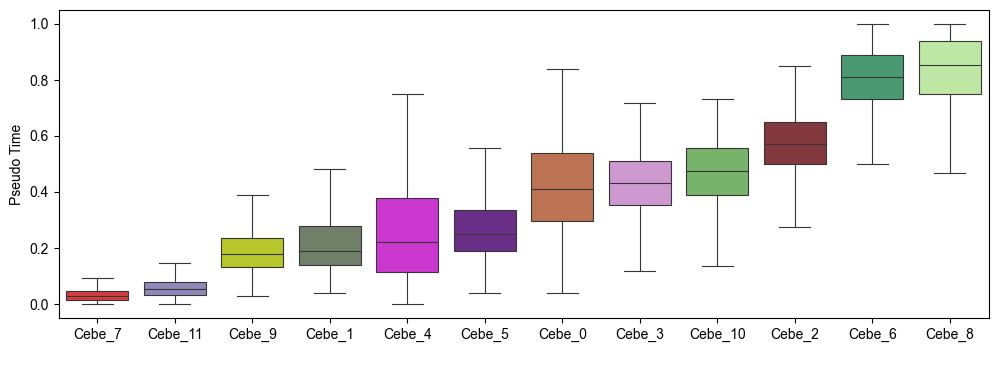

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    data=csv,
    x='dmt_leiden_anno',
    y='ptime',
    hue='dmt_leiden_anno',
    linewidth=0.8,
    palette=colormap,  # 这里可以注释掉，因为我们手动管理颜色
    order=[ 'Cebe_7', 'Cebe_11', 'Cebe_9',
           'Cebe_1','Cebe_4', 'Cebe_5',
           'Cebe_0', 'Cebe_3', 'Cebe_10',
           'Cebe_2', 'Cebe_6', 'Cebe_8',],
    showfliers=False
)
ax.set_xlabel(' ')
ax.set_ylabel('Pseudo Time')
ax.legend(frameon=False)
plt.savefig('/data/work/05.cluster/FuseMap/20251103/4_tracks/pseudotime_box_plot/spatial.pdf', bbox_inches = 'tight')

In [10]:
adatas = []
for name in names:
    data_path = f'/data/work/05.cluster/FuseMap/20251103/4_tracks/single_20251104_1/{name}'
    adata = sc.read_h5ad(data_path)
    adata.obs_names_make_unique()
    adatas.append(adata.obs)

In [11]:
csv = pd.concat(adatas)

In [12]:
csv.groupby('dmt_leiden_anno')[["ptime"]].agg({'ptime': 'mean', }).sort_values('ptime', ascending = False)

,ptime
dmt_leiden_anno,
Cere_sc_9,0.912828
Cere_sc_6,0.909031
Cere_sc_7,0.883847
Cere_sc_8,0.868275
Cere_sc_16,0.720934
Cere_sc_4,0.716232
Cere_sc_14,0.687793
Cere_sc_18,0.681568
Cere_sc_3,0.623118


In [13]:
colormap = {'Cere_sc_22': '#b720f0',
 'Cere_sc_1': '#9ee6fe',
 'Cere_sc_2': '#84e0ee',
 'Cere_sc_14': '#405312',
 'Cere_sc_20': '#1af63c',
 'Cere_sc_7': '#51346b',
 'Cere_sc_19': '#97a50d',
 'Cere_sc_23': '#cdf318',
 'Cere_sc_15': '#728cfd',
 'Cere_sc_5': '#65e03c',
 'Cere_sc_4': '#cb6780',
 'Cere_sc_9': '#b572a1',
 'Cere_sc_13': '#51e78f',
 'Cere_sc_8': '#89c066',
 'Cere_sc_10': '#8163f4',
 'Cere_sc_24': '#c517d2',
 'Cere_sc_17': '#f30494',
 'z_delete': '#557eae',
 'Cere_sc_12': '#c93c35',
 'Cere_sc_21': '#10650a',
 'Cere_sc_3': '#aae898',
 'Cere_sc_16': '#505238',
 'Cere_sc_18': '#1f609e',
 'Cere_sc_6': '#f216bd',
 'Cere_sc_11': '#8945d4'}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


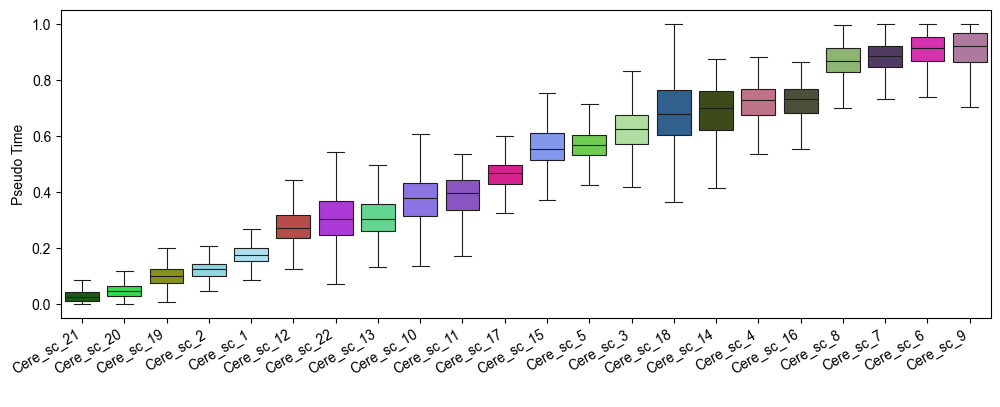

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    data=csv,
    x='dmt_leiden_anno',
    y='ptime',
    hue='dmt_leiden_anno',
    linewidth=0.8,
    palette=colormap,  # 这里可以注释掉，因为我们手动管理颜色
    order=[ 'Cere_sc_21', 'Cere_sc_20', 'Cere_sc_19',
           'Cere_sc_2','Cere_sc_1', 'Cere_sc_12',
           'Cere_sc_22', 'Cere_sc_13', 'Cere_sc_10',
           'Cere_sc_11', 'Cere_sc_17', 'Cere_sc_15',
          'Cere_sc_5', 'Cere_sc_3', 'Cere_sc_18',
           'Cere_sc_14', 'Cere_sc_4', 'Cere_sc_16',
           'Cere_sc_8', 'Cere_sc_7', 'Cere_sc_6',
           'Cere_sc_9'
          ],
    showfliers=False
)
ax.set_xlabel(' ')
ax.set_ylabel('Pseudo Time')
plt.xticks(rotation=30, ha = 'right')
ax.legend(frameon=False)
plt.savefig('/data/work/05.cluster/FuseMap/20251103/4_tracks/pseudotime_box_plot/single.pdf', bbox_inches = 'tight')